# Baseline training: fine-tuning ResNet on EuroSAT

This notebook builds up the training pipeline step by step.

In [58]:
from pathlib import Path

from torchvision.datasets import EuroSAT

DATA_ROOT = Path("../data")

## Load the dataset

In [59]:
dataset = EuroSAT(root=DATA_ROOT, download=True)

print(f"Number of images: {len(dataset)}")
print(f"Classes: {dataset.classes}")

Number of images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Split into train / val / test (stratified)

70/15/15, stratified so each split keeps the same class proportions as the full dataset. Done in two steps: first carve out the test set, then split the remainder into train/val. The test set is set aside now and won't be touched again until final evaluation.

In [60]:
from sklearn.model_selection import train_test_split

labels = [label for _, label in dataset.samples]
indices = list(range(len(dataset)))

train_idx, test_idx = train_test_split(
    indices, test_size=0.15, stratify=labels, random_state=42,
)
train_labels = [labels[i] for i in train_idx]
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.15 / 0.85, stratify=train_labels, random_state=42,
)

print(f"Train: {len(train_idx):5d} ({len(train_idx) / len(dataset):.1%})")
print(f"Val:   {len(val_idx):5d} ({len(val_idx) / len(dataset):.1%})")
print(f"Test:  {len(test_idx):5d} ({len(test_idx) / len(dataset):.1%})")

Train: 18899 (70.0%)
Val:    4051 (15.0%)
Test:   4050 (15.0%)


### Sanity check: class balance preserved across splits

In [61]:
import numpy as np

def class_distribution(idx):
    counts = np.bincount([labels[i] for i in idx], minlength=len(dataset.classes))
    return counts / counts.sum()

print(f"{'class':25s} {'train':>8s} {'val':>8s} {'test':>8s}")
for c, class_name in enumerate(dataset.classes):
    train_pct = class_distribution(train_idx)[c]
    val_pct = class_distribution(val_idx)[c]
    test_pct = class_distribution(test_idx)[c]
    print(f"{class_name:25s} {train_pct:8.1%} {val_pct:8.1%} {test_pct:8.1%}")

class                        train      val     test
AnnualCrop                   11.1%    11.1%    11.1%
Forest                       11.1%    11.1%    11.1%
HerbaceousVegetation         11.1%    11.1%    11.1%
Highway                       9.3%     9.3%     9.3%
Industrial                    9.3%     9.3%     9.3%
Pasture                       7.4%     7.4%     7.4%
PermanentCrop                 9.3%     9.3%     9.3%
Residential                  11.1%    11.1%    11.1%
River                         9.3%     9.3%     9.3%
SeaLake                      11.1%    11.1%    11.1%


## Transforms

Normalization uses the per-channel mean/std computed in `01_explore_eurosat.ipynb`, loaded here from `data/eurosat_stats.json` rather than copy-pasted — a fixed property of the dataset, computed once. We use these EuroSAT-specific stats rather than the ImageNet ones because we're fine-tuning, not doing frozen feature extraction, so it's worth matching the target domain. Augmentation (random flips) is applied to the train split only: satellite tiles have no natural "up", so flipping is a safe, effective augmentation. Val/test only get normalization, so evaluation stays representative of real data.

In [62]:
import json

from torchvision import transforms

with open(DATA_ROOT / "eurosat_stats.json") as f:
    stats = json.load(f)

EUROSAT_MEAN = stats["mean"]
EUROSAT_STD = stats["std"]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

## DataLoaders

`dataset` only has one transform, but train needs augmentation while val/test don't. So we create two `EuroSAT` instances pointing at the same files with different transforms, and apply the already-computed split indices to each via `Subset`.

In [63]:
from torch.utils.data import DataLoader, Subset

train_dataset_full = EuroSAT(root=DATA_ROOT, transform=train_transform)
eval_dataset_full = EuroSAT(root=DATA_ROOT, transform=eval_transform)

train_set = Subset(train_dataset_full, train_idx)
val_set = Subset(eval_dataset_full, val_idx)
test_set = Subset(eval_dataset_full, test_idx)

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 296
Val batches:   64
Test batches:  64


### Sanity check: pull one batch

In [64]:
images, targets = next(iter(train_loader))

print(f"Batch images shape: {images.shape}")  # (batch_size, 3, 64, 64)
print(f"Batch targets shape: {targets.shape}")
print(f"Pixel value range after normalization: [{images.min():.2f}, {images.max():.2f}]")

Batch images shape: torch.Size([64, 3, 64, 64])
Batch targets shape: torch.Size([64])
Pixel value range after normalization: [-2.46, 5.03]


## Reproducibility and device

Fixing the seeds makes weight initialization, dropout, shuffling, and augmentation deterministic across runs — without this, re-running the notebook (or comparing two hyperparameter choices) mixes real effects with random noise. `device` picks the GPU if available; both the model and every batch of data will need to be explicitly moved onto it later with `.to(device)`.

In [65]:
import random

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Visual sanity check: augmented batch

We already checked the batch's shape and value range, but not that the images actually look right after augmentation + normalization. `Normalize` is reversed here (`pixel * std + mean`) to get back displayable images. Catching a broken pipeline (wrong channel order, wrong stats) here costs 10 seconds; catching it after a full training run costs a lot more.

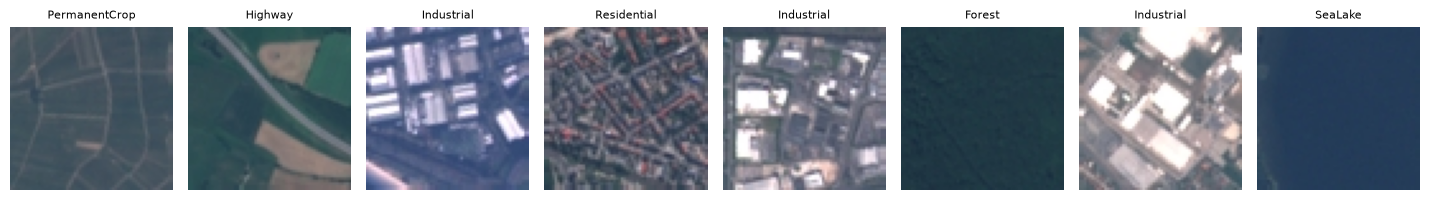

In [66]:
import matplotlib.pyplot as plt

def denormalize(image):
    mean = torch.tensor(EUROSAT_MEAN).view(3, 1, 1)
    std = torch.tensor(EUROSAT_STD).view(3, 1, 1)
    return (image * std + mean).clamp(0, 1)

images, targets = next(iter(train_loader))

n = 8
fig, axes = plt.subplots(1, n, figsize=(n * 1.8, 2))
for i in range(n):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[targets[i]], fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Model definition

Load ResNet18 with its ImageNet-pretrained weights, then replace its final fully-connected layer (`fc`): originally a `Linear(512, 1000)` mapping to 1000 ImageNet classes, swapped for a freshly-initialized `Linear(512, 10)` for our EuroSAT classes. Everything before `fc` (the convolutional backbone) keeps its pretrained weights and stays trainable — this is full fine-tuning, not frozen feature extraction, per the reasoning discussed earlier. The model is then moved onto the GPU.

In [67]:
from torch import nn
from torchvision.models import ResNet18_Weights, resnet18

num_classes = len(dataset.classes)

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


### Sanity check: parameter count and a forward pass

In [68]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Forward pass on one real batch, just to confirm shapes line up end to end
images, targets = next(iter(train_loader))
images, targets = images.to(device), targets.to(device)

with torch.no_grad():
    outputs = model(images)

print(f"Output shape: {outputs.shape}")  # (batch_size, num_classes)

Total parameters:     11,181,642
Trainable parameters: 11,181,642
Output shape: torch.Size([64, 10])


## Loss function and optimizer

`CrossEntropyLoss`: applies softmax to the model's raw logits to get per-class probabilities, then measures how much probability mass was put on the wrong classes. This is the quantity backpropagation differentiates to produce gradients.

`Adam`: uses those gradients to update the weights, adapting the step size per-parameter from the recent gradient history — converges faster and needs less tuning than plain SGD. Learning rate is set lower (`1e-4`) than a from-scratch training run would use, since we're fine-tuning pretrained weights and don't want to overwrite them too aggressively.

In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


## Training loop

One function for a training epoch (forward pass, loss, backward pass, weight update — the loop we talked about) and one for evaluation (same forward pass and loss, but no `backward()`/`optimizer.step()`, wrapped in `torch.no_grad()` since we don't need gradients just to measure accuracy). Both track average loss and accuracy over the epoch.

Each epoch: train on `train_loader`, then evaluate on `val_loader`. Whenever validation accuracy improves, the model's weights are checkpointed to disk — that's the snapshot we'll keep, not necessarily the one from the last epoch (which may already be overfitting).

In [70]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == targets).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        loss = criterion(outputs, targets)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == targets).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

In [71]:
NUM_EPOCHS = 10
CHECKPOINT_PATH = Path("../models/resnet18_eurosat_best.pt")
CHECKPOINT_PATH.parent.mkdir(exist_ok=True)

best_val_acc = 0.0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        marker = "  <- best so far, saved"

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}{marker}"
    )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch  1/10 | train_loss=0.3261 train_acc=0.8976 | val_loss=0.1422 val_acc=0.9538  <- best so far, saved
Epoch  2/10 | train_loss=0.1279 train_acc=0.9574 | val_loss=0.1021 val_acc=0.9652  <- best so far, saved
Epoch  3/10 | train_loss=0.0925 train_acc=0.9680 | val_loss=0.1064 val_acc=0.9632
Epoch  4/10 | train_loss=0.0751 train_acc=0.9740 | val_loss=0.0865 val_acc=0.9716  <- best so far, saved
Epoch  5/10 | train_loss=0.0601 train_acc=0.9804 | val_loss=0.0832 val_acc=0.9724  <- best so far, saved
Epoch  6/10 | train_loss=0.0532 train_acc=0.9823 | val_loss=0.1071 val_acc=0.9659
Epoch  7/10 | train_loss=0.0488 train_acc=0.9833 | val_loss=0.0942 val_acc=0.9714
Epoch  8/10 | train_loss=0.0513 train_acc=0.9844 | val_loss=0.0937 val_acc=0.9704
Epoch  9/10 | train_loss=0.0407 train_acc=0.9857 | val_loss=0.0927 val_acc=0.9701
Epoch 10/10 | train_loss=0.0418 train_acc=0.9857 | val_loss=0.0859 val_acc=0.9743  <- best so far, saved

Best validation accuracy: 0.9743


### Training curves

Watch the gap between train and val curves: if train accuracy keeps climbing while val accuracy plateaus or drops, that's overfitting — the checkpointing above already guards against keeping an overfit final epoch, but the curves make it visible.

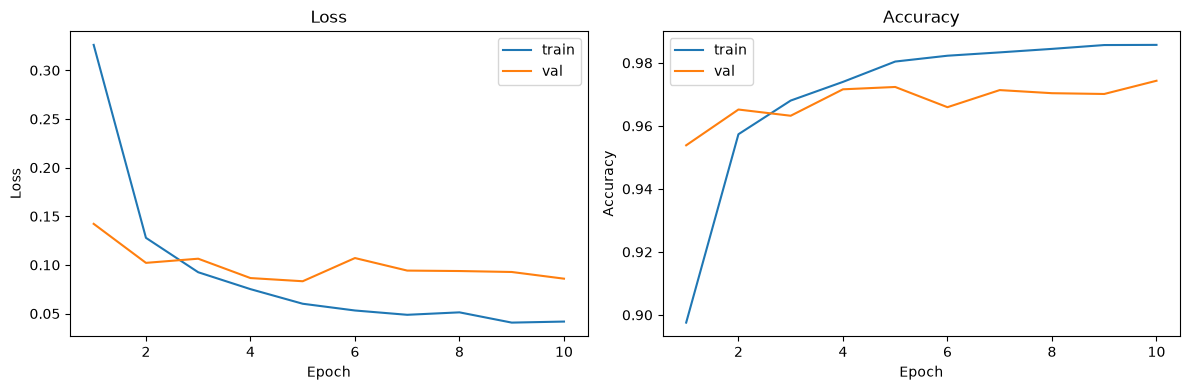

In [72]:
epochs = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, [h["train_loss"] for h in history], label="train")
axes[0].plot(epochs, [h["val_loss"] for h in history], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, [h["train_acc"] for h in history], label="train")
axes[1].plot(epochs, [h["val_acc"] for h in history], label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final evaluation on the test set

This is the one and only time `test_loader` gets used. We reload the best checkpoint (not whatever `model` currently holds in memory, in case later epochs overwrote it) and run it once on the 4,050 held-out images: overall accuracy, per-class precision/recall/F1, and a confusion matrix — which should confirm or rule out the class confusions flagged during exploration (River ↔ SeaLake, AnnualCrop ↔ PermanentCrop).

In [ ]:
# Safety guard: keeps "Run All" (or an accidental re-run) from touching the test
# set before it's actually time. Flip to True only when ready to reveal the result.
RUN_FINAL_EVALUATION = False

In [74]:
if RUN_FINAL_EVALUATION:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test loss:     {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
else:
    print("Skipped — set RUN_FINAL_EVALUATION = True above to run the final test evaluation.")

Test loss:     0.0827
Test accuracy: 0.9756


### Per-class precision, recall, F1

Overall accuracy hides class-level weaknesses — a model can be great on the 5 easy classes and quietly bad on 2 hard ones while still posting a good aggregate number. `classification_report` breaks that down.

In [75]:
from sklearn.metrics import classification_report, confusion_matrix


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(targets)
    return torch.cat(all_preds).numpy(), torch.cat(all_targets).numpy()


if RUN_FINAL_EVALUATION:
    y_pred, y_true = collect_predictions(model, test_loader, device)
    print(classification_report(y_true, y_pred, target_names=dataset.classes, digits=3))
else:
    print("Skipped — set RUN_FINAL_EVALUATION = True above to run the final test evaluation.")

                      precision    recall  f1-score   support

          AnnualCrop      0.967     0.962     0.964       450
              Forest      0.996     0.998     0.997       450
HerbaceousVegetation      0.957     0.982     0.969       450
             Highway      0.978     0.952     0.965       375
          Industrial      0.979     0.995     0.987       375
             Pasture      0.957     0.967     0.962       300
       PermanentCrop      0.946     0.939     0.942       375
         Residential      0.993     0.982     0.988       450
               River      0.981     0.973     0.977       375
             SeaLake      0.993     0.996     0.994       450

            accuracy                          0.976      4050
           macro avg      0.975     0.975     0.975      4050
        weighted avg      0.976     0.976     0.976      4050



### Confusion matrix

Rows are the true class, columns the predicted class — the diagonal is what the model got right. Off-diagonal cells show exactly which classes get mixed up, which is where we'd expect to see River/SeaLake and AnnualCrop/PermanentCrop show up if the visual similarity flagged in `01_explore_eurosat.ipynb` actually trips up the model.

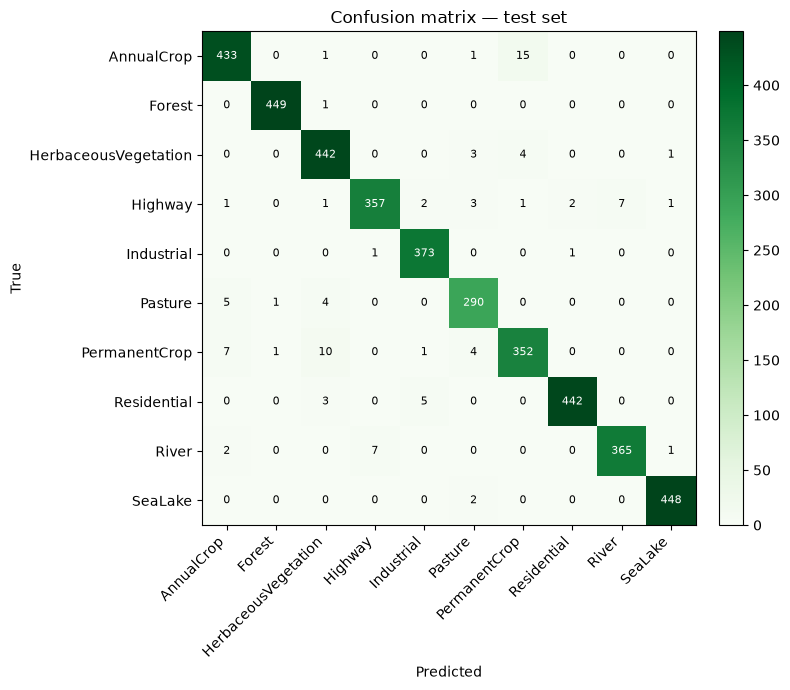

In [76]:
if RUN_FINAL_EVALUATION:
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Greens")

    ax.set_xticks(range(len(dataset.classes)))
    ax.set_yticks(range(len(dataset.classes)))
    ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
    ax.set_yticklabels(dataset.classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion matrix — test set")

    for i in range(len(dataset.classes)):
        for j in range(len(dataset.classes)):
            ax.text(
                j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black",
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped — set RUN_FINAL_EVALUATION = True above to run the final test evaluation.")